<img src = "https://www.udea.edu.co/wps/wcm/connect/udea/721b156e-f6bc-4dc8-8595-8b4731c9a8c7/facultad-ingenieria.png?MOD=AJPERES&CVID=nc5CqsS" widht = 400>

---
<h1><b>Proyecto Final - CNN

- **Integrantes:** Daniela Escobar, Angee Ocampo, Daniel Usme
- **Asignatura:** Deep Learning
- **Profesor:** Hernán Felipe García Arias, Cristian Alfonso Jimenez Castaño
- **Departamento de Ingeniería Electrónica**
- **UdeA**
- **2026-1**

---

In [2]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [3]:
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def astar(grid, start, goal):

    rows, cols = grid.shape

    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}

    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}

    while open_set:

        current = heapq.heappop(open_set)[1]

        if current == goal:

            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)

            return path[::-1]

        neighbors = [
            (current[0]+1, current[1]),
            (current[0]-1, current[1]),
            (current[0], current[1]+1),
            (current[0], current[1]-1)
        ]

        for neighbor in neighbors:

            r, c = neighbor

            if r < 0 or r >= rows:
                continue

            if c < 0 or c >= cols:
                continue

            if grid[r, c] == 1:
                continue

            tentative_g = g_score[current] + 1

            if neighbor not in g_score or tentative_g < g_score[neighbor]:

                came_from[neighbor] = current
                g_score[neighbor] = tentative_g

                f_score[neighbor] = (
                    tentative_g +
                    heuristic(neighbor, goal)
                )

                heapq.heappush(
                    open_set,
                    (f_score[neighbor], neighbor)
                )

    return None

In [4]:
mapa = np.random.choice(
    [0,1],
    size=(20,20),
    p=[0.8,0.2]
)

inicio = (2,3)
meta = (17,15)

path = astar(mapa, inicio, meta)

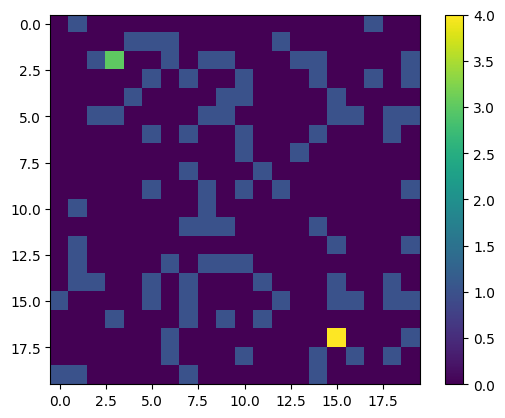

In [5]:
vis = mapa.copy()

if path is not None:
    for p in path:
        vis[p] = 2

vis[inicio] = 3
vis[meta] = 4

plt.imshow(vis)
plt.colorbar()
plt.show()

In [6]:
def generar_mapa(filas=20, columnas=20, prob_obstaculo=0.2):

    mapa = np.random.choice(
        [0, 1],
        size=(filas, columnas),
        p=[1-prob_obstaculo, prob_obstaculo]
    )

    return mapa

def punto_libre(mapa):

    while True:

        x = np.random.randint(0, mapa.shape[0])
        y = np.random.randint(0, mapa.shape[1])

        if mapa[x,y] == 0:
            return (x,y)

def guardar(id_muestra, mapa, inicio, meta, path):

    path_mask = path_to_mask(path, mapa.shape)

    np.savez(
        f"dataset/sample_{id_muestra:05d}.npz",
        mapa=mapa,
        inicio=np.array(inicio),
        meta=np.array(meta),
        path_mask=path_mask
    )

def resample_path(path, target_len):

    path = np.asarray(path, dtype=float)

    if len(path) < 2:
        return np.repeat(path, target_len, axis=0)

    dist = np.sqrt(
        np.sum(np.diff(path, axis=0)**2, axis=1)
    )

    dist = np.insert(np.cumsum(dist), 0, 0)

    total_dist = dist[-1]

    dist_new = np.linspace(
        0,
        total_dist,
        target_len
    )

    fx = interp1d(dist, path[:,0])
    fy = interp1d(dist, path[:,1])

    x_new = fx(dist_new)
    y_new = fy(dist_new)

    return np.column_stack((x_new, y_new))

def path_to_mask(path, shape=(20,20)):

    mask = np.zeros(shape, dtype=np.float32)

    for p in path:

        x = int(round(p[0]))
        y = int(round(p[1]))

        if 0 <= x < shape[0] and 0 <= y < shape[1]:
            mask[x,y] = 1.0

    return mask

In [7]:
# Create the 'dataset' directory if it doesn't exist
if not os.path.exists("dataset"):
    os.makedirs("dataset")
TARGET_LEN = 40

for i in range(5000):

    mapa = generar_mapa()

    inicio = punto_libre(mapa)
    meta = punto_libre(mapa)

    path = astar(mapa, inicio, meta)

    if path is not None:

        path = resample_path(path, TARGET_LEN)

        guardar(i, mapa, inicio, meta, path )

In [8]:
DATASET_DIR = "dataset"

X = []
Y = []

for archivo in os.listdir(DATASET_DIR):

    if not archivo.endswith(".npz"):
        continue

    data = np.load(
        os.path.join(DATASET_DIR, archivo)
    )

    mapa = data["mapa"]
    inicio = data["inicio"]
    meta = data["meta"]
    path_mask = data["path_mask"]

    obstacle_channel = mapa.astype(np.float32)

    start_channel = np.zeros_like(
        obstacle_channel,
        dtype=np.float32
    )

    goal_channel = np.zeros_like(
        obstacle_channel,
        dtype=np.float32
    )

    start_channel[
        inicio[0],
        inicio[1]
    ] = 1.0

    goal_channel[
        meta[0],
        meta[1]
    ] = 1.0

    entrada = np.stack(
        [
            obstacle_channel,
            start_channel,
            goal_channel
        ],
        axis=-1
    )

    X.append(entrada)
    Y.append(path_mask[..., np.newaxis])

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print(X.shape)
print(Y.shape)

(4920, 20, 20, 3)
(4920, 20, 20, 1)


In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3936, 20, 20, 3)
(984, 20, 20, 3)


In [10]:
def dice_coef(y_true, y_pred, smooth=1e-6):

    y_true = tf.cast(y_true, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(
        y_true_f * y_pred_f
    )

    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true_f)
        + tf.reduce_sum(y_pred_f)
        + smooth
    )

def dice_loss(y_true, y_pred):

    return 1.0 - dice_coef(
        y_true,
        y_pred
    )

def bce_dice_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    dice = dice_loss(
        y_true,
        y_pred
    )

    return bce + dice

def iou_coef(y_true, y_pred, smooth=1e-6):

    y_true = tf.cast(y_true, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])

    y_pred_f = tf.reshape(
        tf.cast(y_pred > 0.5, tf.float32),
        [-1]
    )

    intersection = tf.reduce_sum(
        y_true_f * y_pred_f
    )

    union = (
        tf.reduce_sum(y_true_f)
        + tf.reduce_sum(y_pred_f)
        - intersection
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )

ResNet

In [11]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    Activation,
    Add
)

def residual_block(x, filters):

    shortcut = x

    x = Conv2D(
        filters,
        (3,3),
        padding='same'
    )(x)

    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(
        filters,
        (3,3),
        padding='same'
    )(x)

    x = BatchNormalization()(x)

    x = Add()([shortcut, x])

    x = Activation('relu')(x)

    return x

In [12]:
from tensorflow.keras.models import Model

inputs = Input(shape=(20,20,3))

# Proyección inicial
x = Conv2D(
    32,
    (3,3),
    padding='same',
    activation='relu'
)(inputs)

# Bloques residuales

x = residual_block(x, 32)

x = residual_block(x, 32)

x = residual_block(x, 32)

# Refinamiento final

x = Conv2D(
    64,
    (3,3),
    padding='same',
    activation='relu'
)(x)

outputs = Conv2D(
    1,
    (1,1),
    activation='sigmoid'
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 20, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 20, 20,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 20, 20,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 20, 20,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 20, 20,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 20, 20,    │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 20,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 20,    │          0 │ conv2d[0][0],     │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 20, 20,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 20, 20,    │      9,248 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 20,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 20, 20,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 20, 20,    │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 20,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 20,    │          0 │ activation_1[0][… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 20, 20,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 20, 20,    │      9,248 │ activation_3[0][

 Total params: 75,713 (295.75 KB)

 Trainable params: 75,329 (294.25 KB)

 Non-trainable params: 384 (1.50 KB)

In [13]:
model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=[
        'accuracy',
        dice_coef,
        iou_coef
    ]
)

In [25]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

checkpoint = ModelCheckpoint(
    "best_resnet.keras",
    monitor="val_dice_coef",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    Y_train,
    validation_split=0.1,
    epochs=60,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 25s 224ms/step - accuracy: 0.9858 - dice_coef: 0.7772 - iou_coef: 0.6705 - loss: 0.2865 - val_accuracy: 0.9749 - val_dice_coef: 0.5808 - val_iou_coef: 0.4185 - val_loss: 0.5436
Epoch 2/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 229ms/step - accuracy: 0.9863 - dice_coef: 0.7852 - iou_coef: 0.6811 - loss: 0.2766 - val_accuracy: 0.9753 - val_dice_coef: 0.6010 - val_iou_coef: 0.4388 - val_loss: 0.5349
Epoch 3/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 25s 224ms/step - accuracy: 0.9869 - dice_coef: 0.7938 - iou_coef: 0.6926 - loss: 0.2660 - val_accuracy: 0.9699 - val_dice_coef: 0.5816 - val_iou_coef: 0.4293 - val_loss: 0.5532
Epoch 4/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 25s 225ms/step - accuracy: 0.9876 - dice_coef: 0.8058 - iou_coef: 0.7081 - loss: 0.2514 - val_accuracy: 0.9747 - val_dice_coef: 0.5872 - val_iou_coef: 0.4290 - val_loss: 0.5517
Epoch 5/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 26s 234ms/step - accuracy: 0.9878 - dice_coef: 0.8100 - iou_coef: 0.7122 - loss: 0.2460 - va

In [26]:
results = model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

print("Loss:", results[0])
print("Accuracy:", results[1])
print("Dice:", results[2])
print("IoU:", results[3])

Loss: 0.5330842137336731
Accuracy: 0.972309410572052
Dice: 0.6101397275924683
IoU: 0.4508898854255676


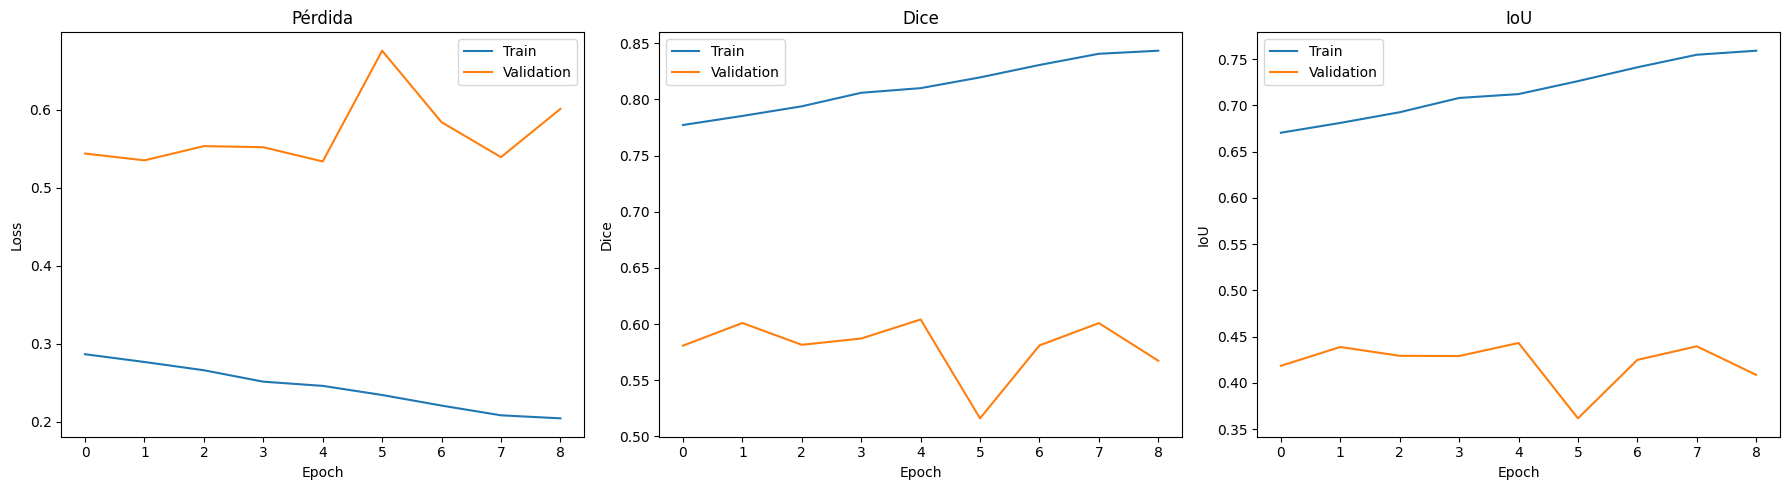

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

# =====================
# LOSS
# =====================

axes[0].plot(
    history.history['loss'],
    label='Train'
)

axes[0].plot(
    history.history['val_loss'],
    label='Validation'
)

axes[0].set_title("Pérdida")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# =====================
# DICE
# =====================

axes[1].plot(
    history.history['dice_coef'],
    label='Train'
)

axes[1].plot(
    history.history['val_dice_coef'],
    label='Validation'
)

axes[1].set_title("Dice")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].legend()

# =====================
# IOU
# =====================

axes[2].plot(
    history.history['iou_coef'],
    label='Train'
)

axes[2].plot(
    history.history['val_iou_coef'],
    label='Validation'
)

axes[2].set_title("IoU")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("IoU")
axes[2].legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


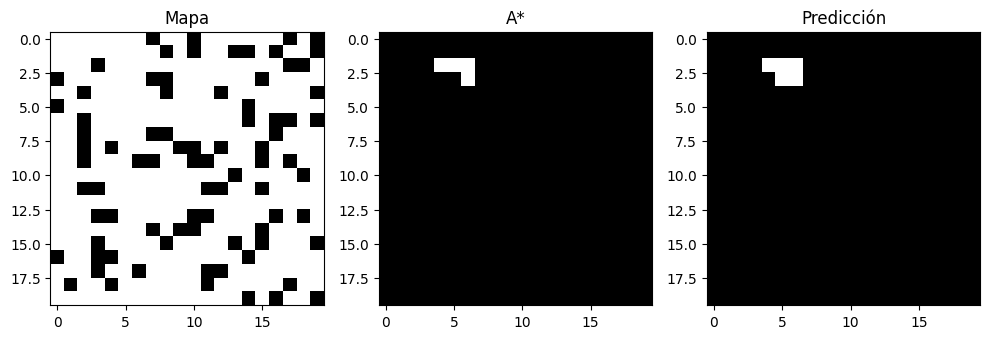

In [37]:
idx = np.random.randint(len(X_test))

pred = model.predict(
    X_test[idx:idx+1]
)[0,:,:,0]

real = Y_test[idx,:,:,0]

mapa = X_test[idx,:,:,0]

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(mapa,cmap='gray_r')
plt.title("Mapa")

plt.subplot(132)
plt.imshow(real,cmap='gray')
plt.title("A*")

plt.subplot(133)
plt.imshow(pred > 0.3,cmap='gray')
plt.title("Predicción")

plt.show()

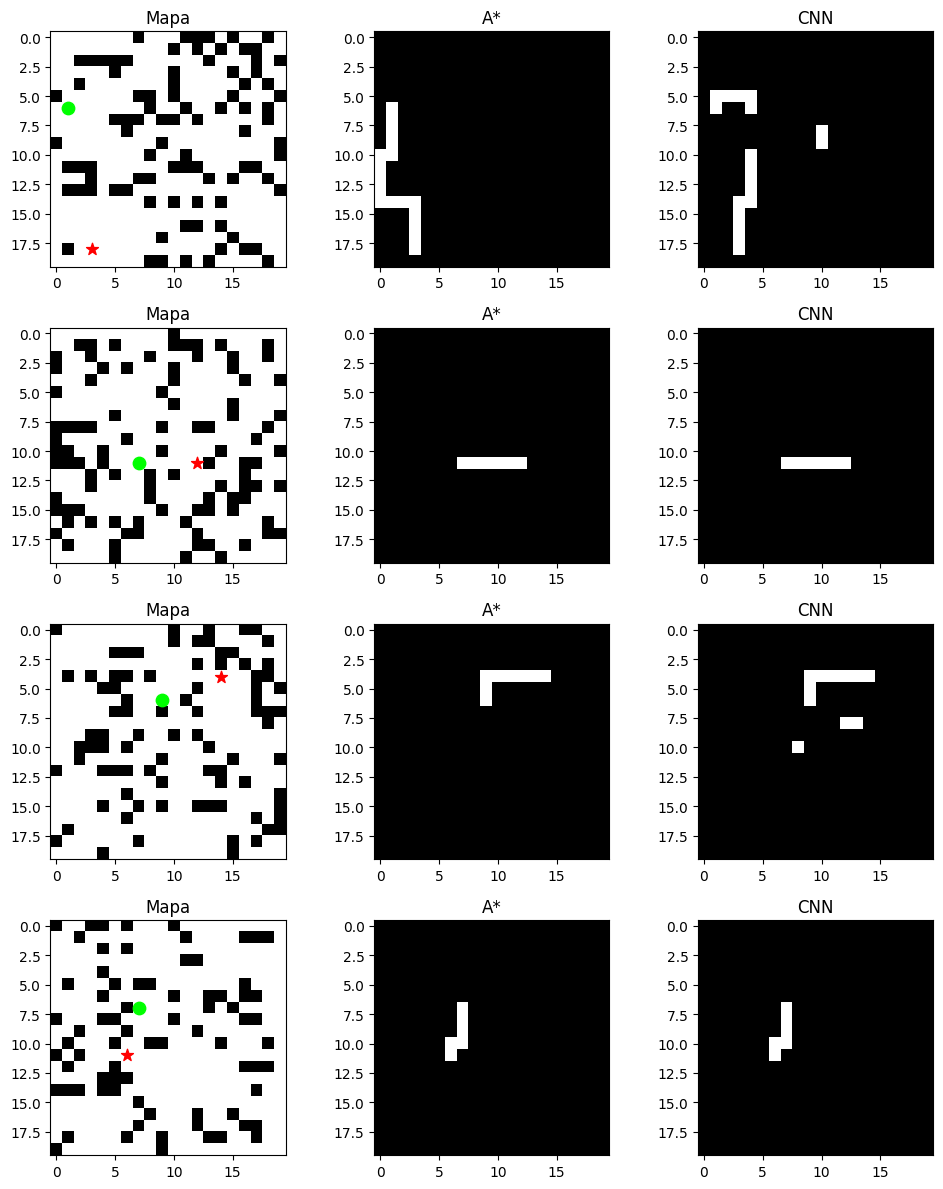

In [49]:
n = 4

fig, axes = plt.subplots(
    n,
    3,
    figsize=(10, 3*n)
)

for i in range(n):

    idx = np.random.randint(len(X_test))

    pred = model.predict(
        X_test[idx:idx+1],
        verbose=0
    )[0,:,:,0]

    real = Y_test[idx,:,:,0]

    mapa = X_test[idx,:,:,0]

    axes[i,0].imshow(
        mapa,
        cmap='gray_r'
    )
    axes[i,0].set_title("Mapa")

    axes[i,1].imshow(
        real,
        cmap='gray'
    )
    axes[i,1].set_title("A*")

    axes[i,2].imshow(
        pred > 0.5,
        cmap='gray'
    )
    axes[i,2].set_title("CNN")


    start = np.argwhere(
        X_test[idx,:,:,1] == 1
    )[0]

    goal = np.argwhere(
        X_test[idx,:,:,2] == 1
    )[0]

    axes[i,0].scatter(
        start[1],
        start[0],
        c='lime',
        s=80,
        marker='o',
        label='Inicio'
    )

    axes[i,0].scatter(
        goal[1],
        goal[0],
        c='red',
        s=80,
        marker='*',
        label='Meta'
    )

plt.tight_layout()
plt.show()

La CNN es capaz de predecir la forma general de las trayectorias generadas mediante A*. En trayectorias simples y de corta longitud se observan predicciones muy cercanas a la solución objetivo, mientras que en trayectorias más complejas aparecen fragmentaciones y errores locales. Esto sugiere que el modelo logra capturar patrones espaciales relevantes del entorno, aunque presenta limitaciones para garantizar la continuidad completa de las rutas generadas.